# DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING

### 1. Data Exploration and Preprocessing:

##### ●	Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder,LabelEncoder

In [2]:
df=pd.read_csv(r"C:\Users\tilna\Downloads\Data Trasformation (1)\adult_with_headers (1).csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.shape

(32561, 15)

In [5]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df.replace(['?'], np.nan, inplace=True)


In [8]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

##### Handle missing values as per the best practices (imputation, removal, etc.).

In [9]:
df.fillna({'workclass':df.workclass.mode()[0],
           'occupation':df.occupation.mode()[0],
           'native_country':df['native_country'].mode()[0]},inplace=True)

In [10]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [11]:
# duplicates
df.duplicated().sum()

np.int64(24)

In [12]:
#drop_duplicates
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum()

np.int64(0)

<Axes: >

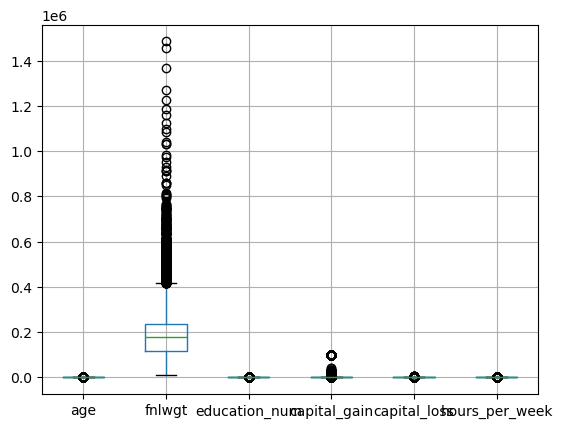

In [13]:
#outliers check
df.boxplot()

In [14]:
#outlier capping
def outlier_capping(df,columns):
    Q1=df[columns].quantile(0.25)
    Q3=df[columns].quantile(0.75)
    IQR=Q3-Q1
    lowwer_ext=Q1-1.5*IQR
    upper_ext=Q3+1.5*IQR
    df[columns]=df[columns].apply(lambda x: lowwer_ext if x<lowwer_ext else upper_ext if x>upper_ext else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

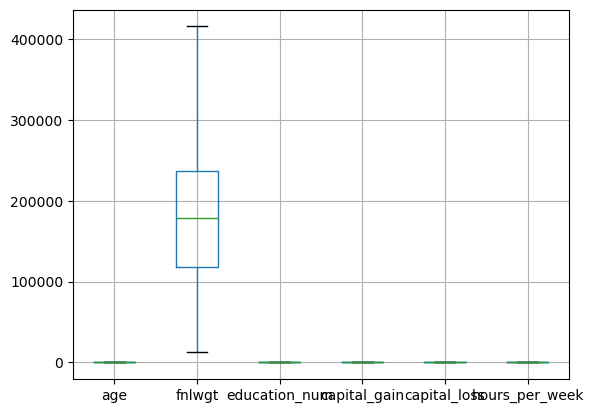

In [15]:
df.boxplot()
plt.show()

In [16]:
target=df['income']
features=df.drop(columns=['income'])

In [17]:
#label encoding on target
lab_enc=LabelEncoder()
target=lab_enc.fit_transform(target)

### 2. Encoding Techniques:

##### ●	Apply One-Hot Encoding to categorical variables with less than 5 categories.

In [18]:
#unique num
for i in features.select_dtypes(['object']):
    num_of_categories=features[i].nunique()
    print(f'{i}:{num_of_categories}')

workclass:8
education:16
marital_status:7
occupation:14
relationship:6
race:5
sex:2
native_country:41


In [19]:
#one_hot
one_hot=OneHotEncoder()
df1=pd.DataFrame(one_hot.fit_transform(features[['sex']]).toarray(),columns=['Female','Male'])

In [20]:
features=features.join([df1])
features.drop(columns=['sex'],inplace=True)

##### ●	Use Label Encoding for categorical variables with more than 5 categories.

In [21]:
for col in ['education','marital_status','occupation','relationship','race','native_country','workclass']:
    features[col] = lab_enc.fit_transform(features[col])

##### ●	Discuss the pros and cons of One-Hot Encoding and Label Encoding.

### 3. Feature Engineering:

##### ●	Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices

In [22]:
def age_group(x):
    if x < 30:
        return "Young"
    elif x <= 50:
        return "Adult"
    else:
        return "Senior"

features["Age_Group"] = features['age'].apply(age_group)

In [23]:
features['Age_Group']=lab_enc.fit_transform(features['Age_Group'])

In [24]:
features

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,Female,Male,Age_Group
0,39.0,6,77516.0,9,13.0,4,0,1,4,0.0,0.0,40.0,38,0.0,1.0,0
1,50.0,5,83311.0,9,13.0,2,3,0,4,0.0,0.0,32.5,38,0.0,1.0,0
2,38.0,3,215646.0,11,9.0,0,5,1,4,0.0,0.0,40.0,38,0.0,1.0,0
3,53.0,3,234721.0,1,7.0,2,5,0,2,0.0,0.0,40.0,38,0.0,1.0,1
4,28.0,3,338409.0,9,13.0,2,9,5,2,0.0,0.0,40.0,4,1.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,27.0,3,257302.0,7,12.0,2,12,5,4,0.0,0.0,38.0,38,1.0,0.0,2
32533,40.0,3,154374.0,11,9.0,2,6,0,4,0.0,0.0,40.0,38,0.0,1.0,0
32534,58.0,3,151910.0,11,9.0,6,0,4,4,0.0,0.0,40.0,38,1.0,0.0,1
32535,22.0,3,201490.0,11,9.0,4,0,3,4,0.0,0.0,32.5,38,0.0,1.0,2


In [25]:
features["EduHours"] = features["education_num"] * features["hours_per_week"]

##### ●	Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.

In [26]:
features['fnlwgt'].skew()

np.float64(0.5481580296455432)

In [27]:
features["fnlwgt"] = np.log1p(features["fnlwgt"])

In [28]:
features['fnlwgt'].skew()

np.float64(-0.9557942311289334)

##### ●	Apply scaling techniques to numerical features:
 #####            a.	Standard Scaling      b. Min-Max Scaling

In [29]:
## a.Standard Scaling
std_sca=StandardScaler()
features[['fnlwgt','age', 'hours_per_week','EduHours']]=std_sca.fit_transform(features[['fnlwgt','age', 'hours_per_week','EduHours']])

In [30]:
## b. Min-Max Scaling
min_max=MinMaxScaler()
features[['education_num']]=min_max.fit_transform(features[['education_num']])

In [31]:
features

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,Female,Male,Age_Group,EduHours
0,0.032472,6,-1.160785,9,0.739130,4,0,1,4,0.0,0.0,-0.194472,38,0.0,1.0,0,0.762344
1,0.844002,5,-1.044523,9,0.739130,2,3,0,4,0.0,0.0,-1.406640,38,0.0,1.0,0,0.019025
2,-0.041304,3,0.489163,11,0.391304,0,5,1,4,0.0,0.0,-0.194472,38,0.0,1.0,0,-0.457461
3,1.065329,3,0.625848,1,0.217391,2,5,0,2,0.0,0.0,-0.194472,38,0.0,1.0,1,-1.067363
4,-0.779058,3,1.215836,9,0.739130,2,9,5,2,0.0,0.0,-0.194472,4,1.0,0.0,2,0.762344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32532,-0.852834,3,0.773971,7,0.652174,2,12,5,4,0.0,0.0,-0.517717,38,1.0,0.0,2,0.274422
32533,0.106247,3,-0.049869,11,0.391304,2,6,0,4,0.0,0.0,-0.194472,38,0.0,1.0,0,-0.457461
32534,1.434206,3,-0.075816,11,0.391304,6,0,4,4,0.0,0.0,-0.194472,38,1.0,0.0,1,-0.457461
32535,-1.221711,3,0.379669,11,0.391304,4,0,3,4,0.0,0.0,-1.406640,38,0.0,1.0,2,-0.972066


### feature selection

In [32]:
from sklearn.ensemble import IsolationForest


In [34]:
iso = IsolationForest(contamination=0.02, random_state=42)
anomalies = iso.fit_predict(features.select_dtypes(include=[np.number]))
features['anomalies'] =anomalies

In [35]:
# -1 = anomaly, 1 = normal
features["anomalies"].value_counts()

anomalies
 1    31886
-1      651
Name: count, dtype: int64

In [36]:
features.drop(columns=['capital_gain','capital_loss'],inplace=True)

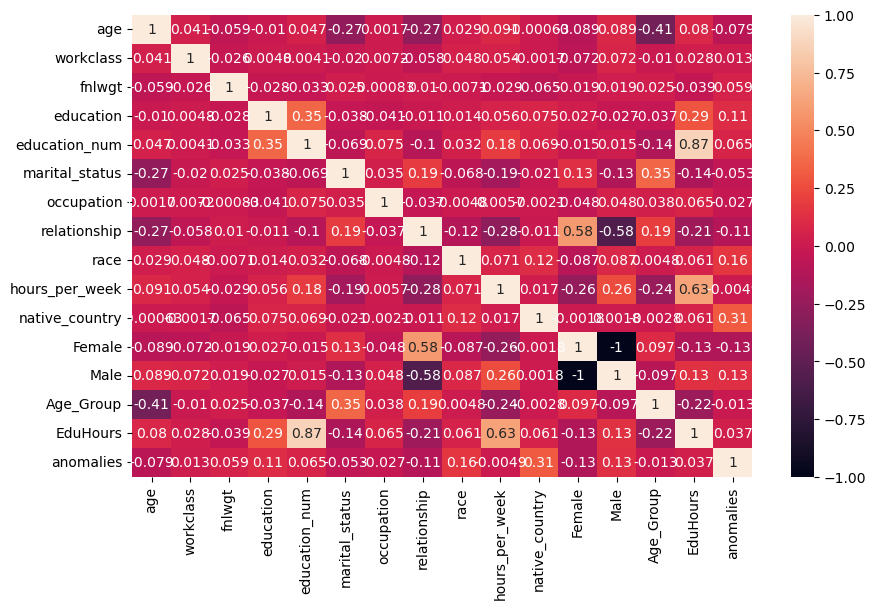

In [37]:
## feature selection
## correlation matrix
plt.figure(figsize=(10,6))
corr=features.corr()
sns.heatmap(corr,annot=True)
plt.show()